In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
using Revise

  Activating project at `~/Github_Projects/JJDFTX.jl`


In [2]:
using PyPlot, PyCall, JJDFTX, LinearAlgebra
interpolate = pyimport("scipy.interpolate").interp1d;
# Kronecker Delta
δ(x,y) = ==(x,y)
z_smearing(z::Real, z_0::Real = 0, smearing::Real = 1) = exp(-(z-z_0)^2/(2*smearing^2))/(smearing*sqrt(2*pi))
num_zs = 40
z_range = range(-10, 10, length = num_zs*2+1);
alpha_hBN = 13*bohrtoangstrom;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
elec_density_up = np.reshape(np.fromfile("../ground_state/Cs-0.325.n_dn"), (54, 54, 168));
elec_density_dn = np.reshape(np.fromfile("../ground_state/Cs-0.325.n_up"), (54, 54, 168));
elec_density = elec_density_up + elec_density_dn;
z_density = np.ndarray.flatten(sum(elec_density, dims=[1, 2]))
z_density = z_density*5419.38/40/54/54/bohrtoangstrom
elec_z_array = range(-20*bohrtoangstrom, 20*bohrtoangstrom, length=168);

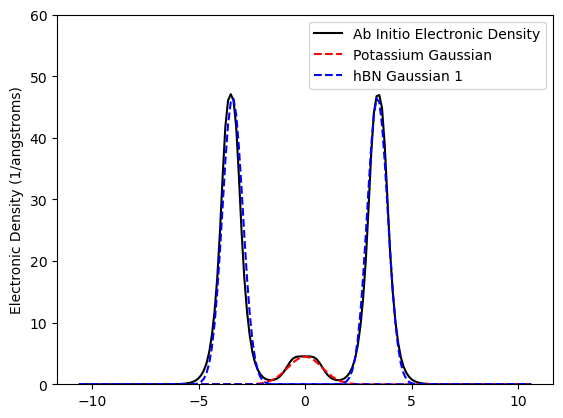

In [4]:
plot(elec_z_array, np.roll(z_density, 56), color="black", label="Ab Initio Electronic Density")
plot(elec_z_array, z_smearing.(elec_z_array, 0, 0.8)*9, color="red", linestyle="dashed", label="Potassium Gaussian")
plot(elec_z_array, z_smearing.(elec_z_array, 3.4, 0.48)*56, color="blue", linestyle="dashed", label="hBN Gaussian 1")
plot(elec_z_array, z_smearing.(elec_z_array, -3.4, 0.48)*56, color="blue", linestyle="dashed")
#xlim(-2, 2)
legend()
ylabel("Electronic Density (1/angstroms)")
ylim(0, 60);